In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

In [3]:
FILE = r"C:\Users\TEJAS KADAM\Desktop\Financial Sample.xlsx"

df = pd.read_excel(FILE)
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully!
Shape: (700, 16)


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014


In [4]:
# Rename columns for easier use
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Add year_month column
df["year_month"] = df["date"].dt.to_period("M")

print("Columns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Columns: ['segment', 'country', 'product', 'discount_band', 'units_sold', 'manufacturing_price', 'sale_price', 'gross_sales', 'discounts', 'sales', 'cogs', 'profit', 'date', 'month_number', 'month_name', 'year', 'year_month']

Data Types:
 segment                           str
country                           str
product                           str
discount_band                     str
units_sold                    float64
manufacturing_price             int64
sale_price                      int64
gross_sales                   float64
discounts                     float64
sales                         float64
cogs                          float64
profit                        float64
date                   datetime64[us]
month_number                    int64
month_name                        str
year                            int64
year_month                  period[M]
dtype: object


In [14]:

# Monthly sales trend
monthly_sales = df.groupby("year_month")["sales"].sum().reset_index()
monthly_sales["year_month"] = monthly_sales["year_month"].astype(str)

# Sales by segment
segment_sales = df.groupby("segment")["sales"].sum().sort_values(ascending=False).reset_index()

# Sales by country
country_sales = df.groupby("country")["sales"].sum().sort_values(ascending=False).reset_index()

# Profit by product
product_profit = df.groupby("product")["profit"].sum().sort_values(ascending=False).reset_index()

# Sales by discount band
discount_sales = df.groupby("discount_band")["sales"].sum().reset_index()


Total Sales      : $118,726,350.26
Total Profit     : $16,893,702.26
Total Units Sold : 1,125,806
Total COGS       : $101,832,648.00
Profit Margin    : 14.23%


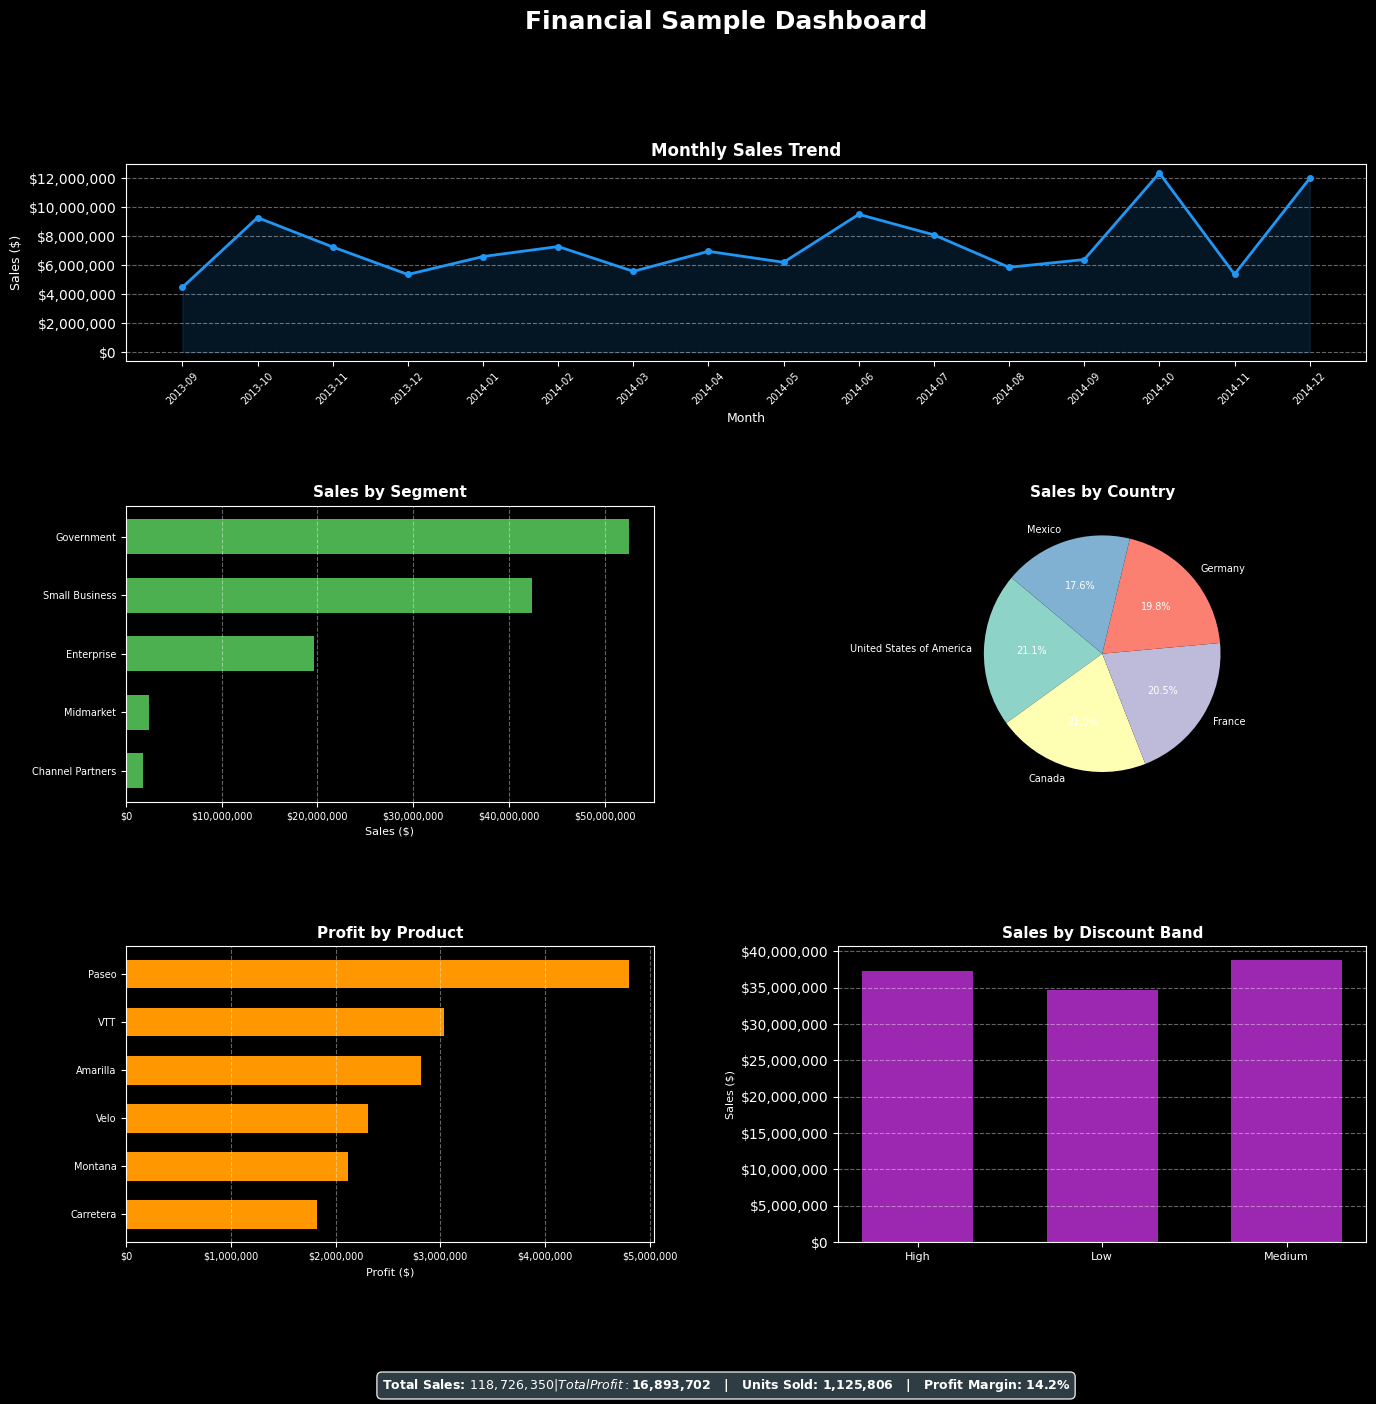

Dashboard saved as 'financial_dashboard.png'


In [23]:

total_sales      = df["sales"].sum()
total_profit     = df["profit"].sum()
total_units      = df["units_sold"].sum()
total_cogs       = df["cogs"].sum()
profit_margin    = (total_profit / total_sales) * 100

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Units Sold : {total_units:,.0f}")
print(f"Total COGS       : ${total_cogs:,.2f}")
print(f"Profit Margin    : {profit_margin:.2f}%")

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Financial Sample Dashboard", fontsize=18, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(nrows=3, ncols=2, figure=fig,
                       height_ratios=[2, 3, 3], hspace=0.55, wspace=0.35)

dollar_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")

# Chart 1 - Monthly Sales Trend
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(monthly_sales["year_month"], monthly_sales["sales"],
         marker="o", color="#2196F3", linewidth=2, markersize=4)
ax1.fill_between(monthly_sales["year_month"], monthly_sales["sales"],
                 alpha=0.15, color="#2196F3")
ax1.set_title("Monthly Sales Trend", fontsize=12, fontweight="bold")
ax1.set_xlabel("Month", fontsize=9)
ax1.set_ylabel("Sales ($)", fontsize=9)
ax1.yaxis.set_major_formatter(dollar_fmt)
ax1.tick_params(axis="x", rotation=45, labelsize=7)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Chart 2 - Sales by Segment
ax2 = fig.add_subplot(gs[1, 0])
ax2.barh(segment_sales["segment"], segment_sales["sales"], color="#4CAF50", height=0.6)
ax2.set_title("Sales by Segment", fontsize=11, fontweight="bold")
ax2.set_xlabel("Sales ($)", fontsize=8)
ax2.xaxis.set_major_formatter(dollar_fmt)
ax2.tick_params(axis="both", labelsize=7)
ax2.invert_yaxis()
ax2.grid(axis="x", linestyle="--", alpha=0.4)

# Chart 3 - Sales by Country (Pie)
ax3 = fig.add_subplot(gs[1, 1])
ax3.pie(country_sales["sales"], labels=country_sales["country"],
        autopct="%1.1f%%", startangle=140,
        colors=plt.cm.Set3.colors, textprops={"fontsize": 7})
ax3.set_title("Sales by Country", fontsize=11, fontweight="bold")

# Chart 4 - Profit by Product
ax4 = fig.add_subplot(gs[2, 0])
ax4.barh(product_profit["product"], product_profit["profit"], color="#FF9800", height=0.6)
ax4.set_title("Profit by Product", fontsize=11, fontweight="bold")
ax4.set_xlabel("Profit ($)", fontsize=8)
ax4.xaxis.set_major_formatter(dollar_fmt)
ax4.tick_params(axis="both", labelsize=7)
ax4.invert_yaxis()
ax4.grid(axis="x", linestyle="--", alpha=0.4)

# Chart 5 - Sales by Discount Band
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(discount_sales["discount_band"], discount_sales["sales"], color="#9C27B0", width=0.6)
ax5.set_title("Sales by Discount Band", fontsize=11, fontweight="bold")
ax5.set_ylabel("Sales ($)", fontsize=8)
ax5.yaxis.set_major_formatter(dollar_fmt)
ax5.tick_params(axis="x", labelsize=8)
ax5.grid(axis="y", linestyle="--", alpha=0.4)

# KPI strip
kpi_text = (f"Total Sales: ${total_sales:,.0f}   |   "
            f"Total Profit: ${total_profit:,.0f}   |   "
            f"Units Sold: {total_units:,.0f}   |   "
            f"Profit Margin: {profit_margin:.1f}%")
fig.text(0.5, 0.005, kpi_text, ha="center", fontsize=9, color="white",
         fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#37474F", alpha=0.85))

plt.savefig("financial_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as 'financial_dashboard.png'")


In [7]:
with pd.ExcelWriter("financial_summary.xlsx", engine="openpyxl") as writer:
    monthly_sales.to_excel(writer,   sheet_name="Monthly Sales",  index=False)
    segment_sales.to_excel(writer,   sheet_name="By Segment",     index=False)
    country_sales.to_excel(writer,   sheet_name="By Country",     index=False)
    product_profit.to_excel(writer,  sheet_name="Product Profit", index=False)
    discount_sales.to_excel(writer,  sheet_name="Discount Band",  index=False)

print("Summary exported to 'financial_summary.xlsx'")

Summary exported to 'financial_summary.xlsx'
